# Tutorial

Variance reduction of a treatment effect estimate by subtracting out variance that a pre-experiment covariate can explain. A smaller variance means narrower confidence intervals and lower p-values in the presence of a treatment effect.

`pfngouin` applies this idea using a learned model (Linear, XGBoost, or TabPFN) fitted on the combined control + treatment data. We then compare methods on two key metrics:

- **p-value** — did we reach significance?
- **95% CI width** — how precise is our effect estimate? (narrower = less uncertainty)

In [21]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
from pfngouin.datasets import make_experiment_data
from tqdm.notebook import tqdm

import pfngouin as pfg

In [22]:
import time

N_RUNS = 10
all_results = []

for run in tqdm(range(N_RUNS)):
    seed = 42 + run
    data = make_experiment_data(N=2000, p_treatment=0.5, effect=1.0, seed=seed)
    control   = data["control"]
    treatment = data["treatment"]
    X_ctrl    = data["X_ctrl"]
    X_trt     = data["X_trt"]

    run_results = []

    # ── No adjustment (baseline) ──────────────────────────────────────────────
    t0 = time.perf_counter()
    r = pg.ttest(treatment, control)
    elapsed = time.perf_counter() - t0
    r = r.assign(method="No adjustment", var_reduction=0.0, elapsed_s=elapsed, run=run)
    run_results.append(r)

    # ── Linear model ──────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    r = pfg.ttest(
        control, treatment,
        covariates_control=X_ctrl,
        covariates_treatment=X_trt,
        model=pfg.LinearModel(),
        random_state=seed,
    )
    elapsed = time.perf_counter() - t0
    r = r.assign(method="LinearModel", elapsed_s=elapsed, run=run)
    run_results.append(r)

    # ── XGBoost (untuned) ─────────────────────────────────────────────────────
    t0 = time.perf_counter()
    r = pfg.ttest(
        control, treatment,
        covariates_control=X_ctrl,
        covariates_treatment=X_trt,
        model=pfg.XGBoostModel(tune=False),
        random_state=seed,
    )
    elapsed = time.perf_counter() - t0
    r = r.assign(method="XGBoostModel (untuned)", elapsed_s=elapsed, run=run)
    run_results.append(r)

    # ── XGBoost (tuned) ───────────────────────────────────────────────────────
    t0 = time.perf_counter()
    r = pfg.ttest(
        control, treatment,
        covariates_control=X_ctrl,
        covariates_treatment=X_trt,
        model=pfg.XGBoostModel(tune=True, n_iter=250, cv=5, n_jobs=-1),
        random_state=seed,
    )
    elapsed = time.perf_counter() - t0
    r = r.assign(method="XGBoostModel (tuned)", elapsed_s=elapsed, run=run)
    run_results.append(r)

    # ── TabPFN ────────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    r = pfg.ttest(
        control, treatment,
        covariates_control=X_ctrl,
        covariates_treatment=X_trt,
        model=pfg.TabPFNModel(),
        random_state=seed,
    )
    elapsed = time.perf_counter() - t0
    r = r.assign(method="TabPFNModel", elapsed_s=elapsed, run=run)
    run_results.append(r)

    all_results.append(pd.concat(run_results, ignore_index=True))

raw = pd.concat(all_results, ignore_index=True)
raw["ci_width"] = raw["CI95"].apply(lambda x: x[1] - x[0])

  0%|          | 0/10 [00:00<?, ?it/s]

In [23]:
METHOD_ORDER = ["No adjustment", "LinearModel", "XGBoostModel (untuned)", "XGBoostModel (tuned)", "TabPFNModel"]

agg = (
    raw.groupby("method")[["p_val", "ci_width", "var_reduction", "elapsed_s"]]
    .agg(["mean", "sem"])
)
agg.columns = ["_".join(c) for c in agg.columns]
agg = agg.reindex(METHOD_ORDER)

display(
    agg[["p_val_mean", "p_val_sem", "ci_width_mean", "ci_width_sem", "var_reduction_mean", "var_reduction_sem", "elapsed_s_mean", "elapsed_s_sem"]]
    .round(4)
    .rename(columns={
        "p_val_mean": "p-value (mean)", "p_val_sem": "p-value (SE)",
        "ci_width_mean": "CI width (mean)", "ci_width_sem": "CI width (SE)",
        "var_reduction_mean": "var reduction (mean)", "var_reduction_sem": "var reduction (SE)",
        "elapsed_s_mean": "runtime s (mean)", "elapsed_s_sem": "runtime s (SE)",
    })
)

,p-value (mean),p-value (SE),CI width (mean),CI width (SE),var reduction (mean),var reduction (SE),runtime s (mean),runtime s (SE)
method,,,,,,,,
No adjustment,0.0714,0.0417,1.845,0.0096,0.0000,0.0000,0.0091,0.0008
LinearModel,0.0512,0.0270,1.491,0.0086,0.3440,0.0081,0.0104,0.0016
XGBoostModel (untuned),0.0617,0.0252,1.575,0.0085,0.2709,0.0093,0.9248,0.1081
XGBoostModel (tuned),0.0522,0.0227,1.449,0.0080,0.3822,0.0070,194.6960,6.4269
TabPFNModel,0.0558,0.0249,1.434,0.0067,0.3959,0.0072,13.4179,1.7967


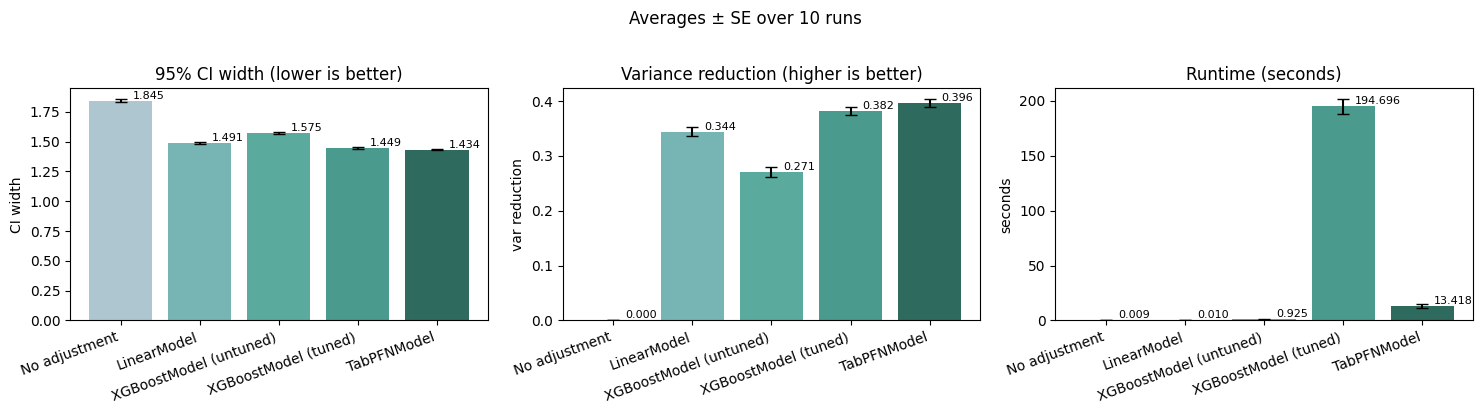

In [ ]:
methods = METHOD_ORDER
colors = ["#aec6cf", "#77b5b5", "#5aab9e", "#4a9a8e", "#2e6b5e"]
x = range(len(methods))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def bar_with_se(ax, means, sems, title, ylabel):
    bars = ax.bar(x, means, color=colors, zorder=2)
    ax.errorbar(x, means, yerr=sems, fmt="none", color="black", capsize=4, linewidth=1.5, zorder=3)
    for bar, val in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2 + 0.15,
            bar.get_height(),
            f"{val:.3f}",
            va="bottom", ha="left", fontsize=8
        )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha="right")

bar_with_se(axes[0], agg["ci_width_mean"], agg["ci_width_sem"],     "95% CI width (lower is better)",    "CI width")
bar_with_se(axes[1], agg["var_reduction_mean"], agg["var_reduction_sem"], "Variance reduction (higher is better)", "var reduction")
bar_with_se(axes[2], agg["elapsed_s_mean"], agg["elapsed_s_sem"],   "Runtime (seconds)",                 "seconds")

fig.suptitle(f"Averages ± SE over {N_RUNS} runs", y=1.02)
fig.tight_layout()
plt.savefig("simulation_results.png", bbox_inches="tight")
